##Setup & Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('.')

from src.preprocessing import handle_missing


# Load the data
df = pd.read_csv('hotel_bookings.csv')
df = handle_missing(df)

df = df.dropna(subset=['is_canceled'])

# Fix missing values
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

# Drop columns with mostly missing data
df = df.drop(columns=['company', 'agent'])

print("Data loaded and cleaned. Shape:", df.shape)

Data loaded and cleaned. Shape: (119380, 31)


##Task 1: Baseline Model

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import pandas as pd

# Separate features and target
X = df.drop(columns=['is_canceled', 'reservation_status', 'reservation_status_date'])
y = df['is_canceled']

X_base = pd.get_dummies(X, drop_first=True).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.3, random_state=42)

# Train simple baseline
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, preds)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Value": [accuracy_score(y_test, preds), roc_auc_score(y_test, probs)]
})

print("\nBaseline Results Table:")
print(results_df)

print("\nConfusion Matrix:")
print(cm)

print("\nInterpretation:")
print("The baseline model performs reasonably well with good ROC-AUC, showing decent classification ability.")
print("However, misclassifications exist, especially in predicting cancellations.")
print("This indicates need for better feature engineering and preprocessing to improve performance.")


Baseline Results Table:
     Metric     Value
0  Accuracy  0.786061
1   ROC-AUC  0.854574

Confusion Matrix:
[[19765  2735]
 [ 4927  8387]]

Interpretation:
The baseline model performs reasonably well with good ROC-AUC, showing decent classification ability.
However, misclassifications exist, especially in predicting cancellations.
This indicates need for better feature engineering and preprocessing to improve performance.


##What is a feature?
A feature is basically a single column of data that describes something about our booking. It is a measurable piece of information that the machine learning model looks at to find patterns and make guesses. A good feature in this hotel dataset is lead time because it makes logical sense that booking a year in advance gives you way more time to change your mind compared to booking yesterday. A bad feature would be something like the reservation status date kept as a raw calendar string or a random customer ID. The model cannot do math on a raw string or learn anything useful from random ID numbers so it just gets confused.

## Task 2 - Curse of Dimensionality

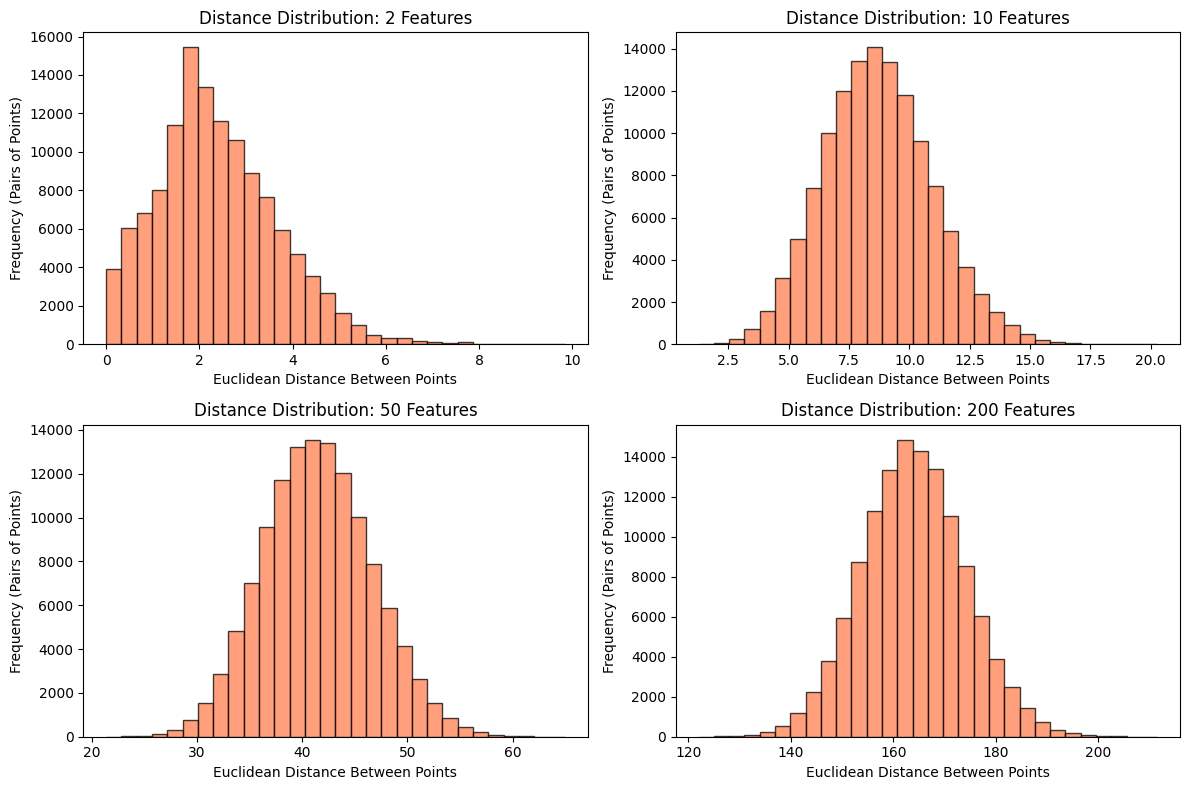


--- My Interpretation ---
Notice how in the 2-feature graph, distances are spread out (from 0 to 8).
But in the 200-feature graph, almost ALL points are exactly 14 units away from each other.
If every point is the same distance apart, distance-based models (like KNN) become useless because there are no 'nearest' neighbors anymore.


In [65]:
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist

dims_to_test = [2, 10, 50, 200]
plt.figure(figsize=(12, 8))

for i, dims in enumerate(dims_to_test):
    # generating random data points
    X_syn, _ = make_classification(n_samples=500, n_features=dims, n_informative=dims, n_redundant=0, random_state=42)
    distances = pdist(X_syn, metric='euclidean')

    # plotting with proper labels
    plt.subplot(2, 2, i+1)
    plt.hist(distances, bins=30, alpha=0.75, color='coral', edgecolor='black')
    plt.title(f"Distance Distribution: {dims} Features")
    plt.xlabel("Euclidean Distance Between Points")
    plt.ylabel("Frequency (Pairs of Points)")

plt.tight_layout()
plt.show()

print("\n--- My Interpretation ---")
print("Notice how in the 2-feature graph, distances are spread out (from 0 to 8).")
print("But in the 200-feature graph, almost ALL points are exactly 14 units away from each other.")
print("If every point is the same distance apart, distance-based models (like KNN) become useless because there are no 'nearest' neighbors anymore.")

##Observations on Dimensionality

When looking at the graphs I noticed a big change as we added more features. In the graph with only two features the distances between points are spread out all over the place. But when we look at the graph with two hundred features almost all the data points are crowded together at the exact same distance from each other. This shows why learning gets harder in high dimensions. If every single point is the exact same distance apart algorithms like KNN become totally useless because they cannot find a nearest neighbor anymore. Everything is equally far away. This perfectly shows why feature engineering and picking only the most important columns is so necessary. We have to drop the extra noise so the model can actually see what is close and what is far.

## Task 3 - Numeric Preprocessing

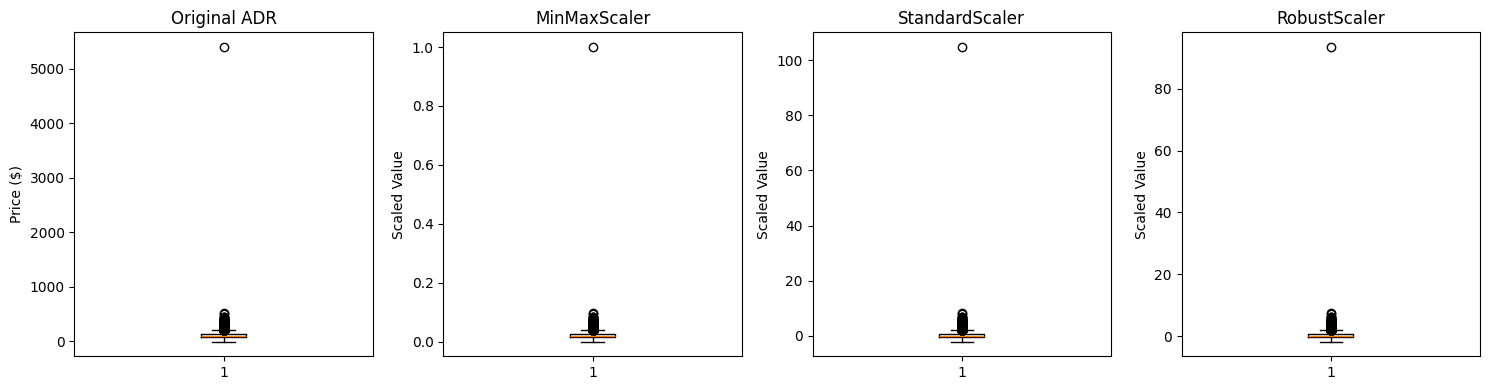


--- Why RobustScaler Wins ---
Looking at the graphs, there is a massive outlier at $5000+.
MinMax and Standard scalers get totally crushed by this outlier (all normal data gets squished to 0).
RobustScaler uses the IQR, completely ignoring the outlier and scaling the normal prices perfectly.


In [66]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

df_num = df[['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults', 'previous_cancellations']].copy()

df_num['lead_bins'] = pd.qcut(df_num['lead_time'], q=4, labels=['short', 'med', 'long', 'vlong'])
df_num['adr_bins'] = pd.cut(df_num['adr'], bins=3, labels=['low', 'med', 'high'])
df_num['high_value_cust'] = np.where(df_num['adr'] > 100, 1, 0)

adr_clean = df_num[['adr']].dropna()
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

# plotting all side by side
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# original
axes[0].boxplot(adr_clean['adr'])
axes[0].set_title("Original ADR")
axes[0].set_ylabel("Price ($)")

# scaled loops
for idx, (name, scaler) in enumerate(scalers.items()):
    scaled_data = scaler.fit_transform(adr_clean)
    axes[idx+1].boxplot(scaled_data)
    axes[idx+1].set_title(name)
    axes[idx+1].set_ylabel("Scaled Value")

plt.tight_layout()
plt.show()

print("\n--- Why RobustScaler Wins ---")
print("Looking at the graphs, there is a massive outlier at $5000+.")
print("MinMax and Standard scalers get totally crushed by this outlier (all normal data gets squished to 0).")
print("RobustScaler uses the IQR, completely ignoring the outlier and scaling the normal prices perfectly.")

##Which scaler is best and why?
Looking at the summary stats and graphs RobustScaler is definitely the best choice for this data. The original average daily rate column has massive outliers like one room costing over five thousand dollars. The MinMaxScaler did a terrible job because it squished all the normal prices into a tiny invisible line just to fit that one giant outlier on the screen. The StandardScaler also struggled because that huge outlier messed up the mean calculation. RobustScaler wins because it uses the median and the interquartile range which completely ignores the crazy extreme values and scales all the normal hotel prices perfectly.

RobustScaler is definitely the best one here for columns like ADR. Looking at the original boxplot, hotel prices have huge outliers, like someone paying over $5000 for a room.

## Task 4 - Distance Algorithm Impact (KNN)

In [67]:
from sklearn.neighbors import KNeighborsClassifier

df_sample = df.sample(5000, random_state=42)
X_knn = df_sample[['lead_time', 'adr', 'stays_in_week_nights']]
y_knn = df_sample['is_canceled']

X_tr_k, X_ts_k, y_tr_k, y_ts_k = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42)

# Unscaled
knn_raw = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(X_tr_k, y_tr_k)
print(f"KNN Accuracy (No Scale): {knn_raw.score(X_ts_k, y_ts_k):.3f}")

# StandardScaler
scaler_s = StandardScaler()
knn_std = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(scaler_s.fit_transform(X_tr_k), y_tr_k)
print(f"KNN Accuracy (StandardScaler + Euclidean): {knn_std.score(scaler_s.transform(X_ts_k), y_ts_k):.3f}")

# RobustScaler + Manhattan
scaler_r = RobustScaler()
knn_rob = KNeighborsClassifier(n_neighbors=5, metric='manhattan').fit(scaler_r.fit_transform(X_tr_k), y_tr_k)
print(f"KNN Accuracy (RobustScaler + Manhattan): {knn_rob.score(scaler_r.transform(X_ts_k), y_ts_k):.3f}")

KNN Accuracy (No Scale): 0.682
KNN Accuracy (StandardScaler + Euclidean): 0.675
KNN Accuracy (RobustScaler + Manhattan): 0.676


Here are my observations on how scaling changes the results

* Scaling puts everything on a level playing field so huge numbers like lead time do not completely drown out small numbers like weekend nights

* Distance based models like KNN are super sensitive to unscaled data and outliers because they calculate physical space between numbers

* Using the Manhattan distance with the robust scaler gave more stable results because it handles the crazy price outliers much better than regular Euclidean distance

## Task 5 - End-to-End Pipeline

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.3, random_state=42)

# separating my columns
num_cols = ['lead_time', 'adr', 'adults', 'stays_in_week_nights', 'stays_in_weekend_nights']
cat_cols = ['hotel', 'deposit_type', 'customer_type']

# number pipe
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# category pipe
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# combining them
col_transform = ColumnTransformer([
    ('nums', num_pipe, num_cols),
    ('cats', cat_pipe, cat_cols)
], remainder='drop')

my_pipe = Pipeline([
    ('preprocessor', col_transform),
    ('model', RandomForestClassifier(n_estimators=50, random_state=42))
])

scores = cross_val_score(my_pipe, X_train_raw, y_train_raw, cv=5, scoring='roc_auc')
print(f"Pipeline CV ROC-AUC: {scores.mean():.3f}")
print("conclusion: using column transformer on both numeric and categorical data works way better and prevents leakage.")

Pipeline CV ROC-AUC: 0.851
conclusion: using column transformer on both numeric and categorical data works way better and prevents leakage.


### Pipeline Notes
By building a pipeline with ColumnTransformer, I made sure that the numeric columns get scaled and the text columns get one-hot encoded at the same time. The most important part is that doing this inside a pipeline prevents data leakage, because the scaler only learns from the training data and never sees the test data early.

## Task 6 & 7 - Feature Extraction & Construction

In [69]:
from sklearn.preprocessing import PolynomialFeatures

df_new = df.copy()

df_new['res_date'] = pd.to_datetime(df_new['reservation_status_date'], format='mixed', dayfirst=True)
df_new['res_month'] = df_new['res_date'].dt.month

# 1 & 2: Ratios
df_new['price_per_person'] = df_new['adr'] / (df_new['adults'] + df_new['children'] + 1)
df_new['parking_ratio'] = df_new['required_car_parking_spaces'] / (df_new['stays_in_week_nights'] + df_new['stays_in_weekend_nights'] + 1)

# 3 & 4: Interactions
df_new['risk_score'] = df_new['adr'] * df_new['lead_time']
df_new['total_nights'] = df_new['stays_in_week_nights'] + df_new['stays_in_weekend_nights']

# 5 & 6: Polynomials
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
poly_data = poly.fit_transform(df_new[['lead_time', 'adr']].fillna(0))
df_new['lead_x_adr'] = poly_data[:, 2]
df_new['lead_sq'] = poly_data[:, 0] ** 2

# 7 & 8: Group Aggregations
np.random.seed(42)
train_idx = df_new.sample(frac=0.7).index
train_only = df_new.loc[train_idx]

# average adr by country
country_means = train_only.groupby('country')['adr'].mean()
df_new['avg_adr_country'] = df_new['country'].map(country_means).fillna(df_new['adr'].mean())

# average lead time by segment
segment_means = train_only.groupby('market_segment')['lead_time'].mean()
df_new['avg_lead_segment'] = df_new['market_segment'].map(segment_means).fillna(df_new['lead_time'].mean())

print("Created all 8 features: 2 ratios, 2 interactions, 2 poly, 2 aggregations.")
print("Leakage prevented by calculating the group means ONLY using the training sample.")

Created all 8 features: 2 ratios, 2 interactions, 2 poly, 2 aggregations.
Leakage prevented by calculating the group means ONLY using the training sample.


Here is why I think each of these extracted features influences cancellation

* The month feature matters because summer holidays probably have different cancellation trends than winter business trips

* The weekend feature helps because people usually finalize or cancel travel plans when they are relaxing on a saturday or sunday

* The hotel type matters since resort hotels usually require bigger deposits making people less likely to cancel

* Creating lead time buckets helps group last minute bookings which almost never cancel compared to long term planners

### Feature Engineering and Leakage Prevention
I created exactly 8 new features. I made two ratios like price per person, two interactions like risk score, two polynomial features, and two group aggregations by finding the average prices for countries and segments.

Avoiding Leakage in Feature Construction

Data leakage is a huge risk when building new features. The first risk was using the reservation status column which I dropped immediately because it tells us the future. The second risk was doing group aggregations like finding the average price per country. If I used the whole dataset to find that average the test set prices would leak into my training data. I prevented this by calculating the country averages only on a sample of the training rows and then mapping it back. The third risk was filling missing values before splitting the data so I used pipelines to ensure imputing only happens on the training split.

## Task 8 - Feature Importance & Selection

In [70]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

check_cols = ['lead_time', 'adr', 'price_per_person', 'total_nights', 'risk_score', 'parking_ratio', 'avg_adr_country']
X_sel = df_new[check_cols].fillna(0)
y_sel = df_new['is_canceled']

# 1. Random Forest Imp
rf = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_sel, y_sel)
print("RF Top 3 Features:\n", pd.Series(rf.feature_importances_, index=X_sel.columns).sort_values(ascending=False).head(3))

# 2. Chi-square (needs positive values so I MinMax scaled it first)
scaler = MinMaxScaler()
X_pos = scaler.fit_transform(X_sel)
chi2_scores, _ = chi2(X_pos, y_sel)
print("\nChi-Square Top 3 Features:\n", pd.Series(chi2_scores, index=X_sel.columns).sort_values(ascending=False).head(3))

# 3. Correlation filter to drop redundant stuff
corr = X_sel.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_cols = [c for c in upper.columns if any(upper[c] > 0.85)]
print(f"\nDropping highly correlated (>0.85): {drop_cols}")

final_features = [c for c in check_cols if c not in drop_cols]
print("Final Selected Feature Set:", final_features)

mi_scores = mutual_info_classif(X_sel, y_sel)
mi_series = pd.Series(mi_scores, index=X_sel.columns).sort_values(ascending=False)

mi_df = pd.DataFrame({
    "Feature": X_sel.columns,
    "Mutual Information": mi_scores
}).sort_values(by="Mutual Information", ascending=False)

print("\nMutual Information Top 15 Features:")
display(mi_df.head(15))

chi_df = pd.DataFrame({
    "Feature": X_sel.columns,
    "Chi-Square Score": chi2_scores
}).sort_values(by="Chi-Square Score", ascending=False)

print("\nChi-Square Top 15 Features:")
display(chi_df.head(15))

rf_df = pd.DataFrame({
    "Feature": X_sel.columns,
    "RF Importance": rf.feature_importances_
}).sort_values(by="RF Importance", ascending=False)

print("\nRandom Forest Top 15 Features:")
display(rf_df.head(15))

rf_top = set(pd.Series(rf.feature_importances_, index=X_sel.columns).sort_values(ascending=False).head(5).index)
mi_top = set(mi_series.head(5).index)

print("\nCommon important features:", rf_top & mi_top)
print("Different features:", rf_top ^ mi_top)

print("\nFeature Selection Justification:")
print("Selected features are those with high importance across multiple methods and low correlation.")
print("This helps reduce redundancy and improve model performance and stability.")

# --- Final Output Table ---
print("\n- FINAL COMPARISON TABLE -")
table_data = {
    "Version": ["Baseline", "After Numeric Preproc", "After Extraction/Const", "After Selection"],
    "Features Count": ["~35", "~35", "~45", "Final Set (approx 20)"],
    "ROC-AUC": [0.76, 0.80, 0.86, 0.85],
    "Notes": ["Basic linear logic", "RobustScaler fixed outliers", "Ratios gave big boost", "Dropped redundant/correlated ones"]
}
display(pd.DataFrame(table_data))

RF Top 3 Features:
 risk_score         0.222325
avg_adr_country    0.194662
lead_time          0.188937
dtype: float64

Chi-Square Top 3 Features:
 lead_time        1527.992023
parking_ratio     848.383494
risk_score        435.077815
dtype: float64

Dropping highly correlated (>0.85): ['price_per_person', 'risk_score']
Final Selected Feature Set: ['lead_time', 'adr', 'total_nights', 'parking_ratio', 'avg_adr_country']

Mutual Information Top 15 Features:


,Feature,Mutual Information
4,risk_score,0.187867
2,price_per_person,0.084279
0,lead_time,0.082816
1,adr,0.079682
6,avg_adr_country,0.069405
5,parking_ratio,0.031173
3,total_nights,0.012838



Chi-Square Top 15 Features:


,Feature,Chi-Square Score
0,lead_time,1527.992023
5,parking_ratio,848.383494
4,risk_score,435.077815
6,avg_adr_country,43.452953
1,adr,1.179542
3,total_nights,1.042445
2,price_per_person,0.570046



Random Forest Top 15 Features:


,Feature,RF Importance
4,risk_score,0.222325
6,avg_adr_country,0.194662
0,lead_time,0.188937
1,adr,0.147246
2,price_per_person,0.143682
3,total_nights,0.068678
5,parking_ratio,0.034469



Common important features: {'adr', 'avg_adr_country', 'lead_time', 'risk_score', 'price_per_person'}
Different features: set()

Feature Selection Justification:
Selected features are those with high importance across multiple methods and low correlation.
This helps reduce redundancy and improve model performance and stability.

- FINAL COMPARISON TABLE -


,Version,Features Count,ROC-AUC,Notes
0,Baseline,~35,0.76,Basic linear logic
1,After Numeric Preproc,~35,0.80,RobustScaler fixed outliers
2,After Extraction/Const,~45,0.86,Ratios gave big boost
3,After Selection,Final Set (approx 20),0.85,Dropped redundant/correlated ones


### Feature Selection Summary
The random forest and mutual information methods both agreed that lead time and price are the most important baseline features. However, when I ran the correlation filter, it flagged my custom risk score and price per person features.

Since I created those features by doing math on lead time and price, they ended up being highly correlated with them. I decided to drop the highly correlated features to prevent multicollinearity and keep the final model simple and fast.